# Predictive Analytics baseret på IoT-data fra vindmøller

**Gruppemedlemmer:**
- Zakaria Mohammadi
- Alexander Lindqvist
- Mohammed Omair Ali
- Mohamad Kamal Fadi Hamad

**Fag:** Predictive Analytics  

**Dato:** 10 Maj 2026

---

## Introduktion

I denne notebook analyserer vi SCADA-data fra en vindmølle for virksomheden **Intelligent IoT Solutions A/S**. Formålet er at:

- Analysere vindmøllens produktion
- Undersøge sammenhænge mellem vindhastighed, vindretning og effektproduktion
- Træne en supervised machine learning-model til predictive analytics
- Diskutere datakvalitet, modelbegrænsninger og forretningsværdi

Datasættet `T1.csv` indeholder ca. 50.000 målinger fra 2018 (én måling hvert 10. minut).

---

## Del 1 — Dataforståelse og datakvalitet

I denne del indlæser vi datasættet og undersøger dets struktur, datatyper, manglende værdier og outliers for at vurdere om det er egnet til predictive analytics.

### 1.1 Import af biblioteker

In [1]:
# Import af nødvendige biblioteker
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Indstillinger for visualiseringer
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 6)

# Ignorer advarsler for renere output
import warnings
warnings.filterwarnings('ignore')

print("✅ Alle biblioteker er importeret korrekt")

✅ Alle biblioteker er importeret korrekt


### 1.2 Indlæsning af datasæt

In [2]:
# Indlæs SCADA-data fra vindmøllen
df = pd.read_csv('T1.csv')

# Vis de første 5 rækker
print(f"Datasættets størrelse: {df.shape[0]} rækker og {df.shape[1]} kolonner")
print()
df.head()

Datasættets størrelse: 50530 rækker og 5 kolonner



,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


### 1.3 Beskrivelse af kolonner

Datasættet indeholder følgende 5 kolonner:

| Kolonne | Beskrivelse | Enhed |
|---------|-------------|-------|
| **Date/Time** | Tidspunkt for målingen (hver 10. minut) | dato/tid |
| **LV ActivePower (kW)** | Den faktiske aktive effekt produceret af vindmøllen | kW |
| **Wind Speed (m/s)** | Vindhastighed målt ved møllens nacelle | m/s |
| **Theoretical_Power_Curve (KWh)** | Den teoretiske effekt møllen burde producere ved den givne vindhastighed (ifølge producentens specifikationer) | kWh |
| **Wind Direction (°)** | Vindretning i grader (0–360°) | grader |

Datasættet repræsenterer SCADA-data (Supervisory Control and Data Acquisition) fra én vindmølle og dækker perioden 1. januar 2018 til 31. december 2018.

### 1.4 Datatyper og manglende værdier

In [3]:
# Vis info om datatyper
print("=== DATATYPER ===")
df.info()

print("\n=== MANGLENDE VÆRDIER ===")
print(df.isnull().sum())

print("\n=== DUPLIKEREDE RÆKKER ===")
print(f"Antal duplikater: {df.duplicated().sum()}")

=== DATATYPER ===
<class 'pandas.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date/Time                      50530 non-null  str    
 1   LV ActivePower (kW)            50530 non-null  float64
 2   Wind Speed (m/s)               50530 non-null  float64
 3   Theoretical_Power_Curve (KWh)  50530 non-null  float64
 4   Wind Direction (°)             50530 non-null  float64
dtypes: float64(4), str(1)
memory usage: 1.9 MB

=== MANGLENDE VÆRDIER ===
Date/Time                        0
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64

=== DUPLIKEREDE RÆKKER ===
Antal duplikater: 0


### 1.5 Konvertering af Date/Time og statistisk oversigt

Vi konverterer `Date/Time` fra tekst til datetime, så vi senere kan udtrække `Hour`, `Day`, `Month` osv. til feature engineering. Derefter ser vi på en statistisk oversigt over de numeriske kolonner.

In [4]:
# Konverter Date/Time fra tekst til rigtig datetime
df['Date/Time'] = pd.to_datetime(df['Date/Time'], format='%d %m %Y %H:%M')

print("Datatyper efter konvertering:")
print(df.dtypes)

print("\n=== STATISTISK OVERSIGT ===")
df.describe()

Datatyper efter konvertering:
Date/Time                        datetime64[us]
LV ActivePower (kW)                     float64
Wind Speed (m/s)                        float64
Theoretical_Power_Curve (KWh)           float64
Wind Direction (°)                      float64
dtype: object

=== STATISTISK OVERSIGT ===


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
count,50530,50530.000000,50530.000000,50530.000000,50530.000000
mean,2018-07-01 20:01:30.065307,1307.684332,7.557952,1492.175463,123.687559
min,2018-01-01 00:00:00,-2.471405,0.000000,0.000000,0.000000
25%,2018-04-03 05:22:30,50.677890,4.201395,161.328167,49.315437
50%,2018-06-30 16:15:00,825.838074,7.104594,1063.776283,73.712978
75%,2018-09-26 18:57:30,2482.507568,10.300020,2964.972462,201.696720
max,2018-12-31 23:50:00,3618.732910,25.206011,3600.000000,359.997589
std,NaN,1312.459242,4.227166,1368.018238,93.443736


### 1.6 Identifikation af outliers

Vi bruger boxplots til visuelt at identificere outliers i de numeriske kolonner. Boxplots viser:
- **Boksen**: 25%–75% af data (interkvartil-området)
- **Stregen i midten**: medianen
- **Punkter udenfor**: potentielle outliers

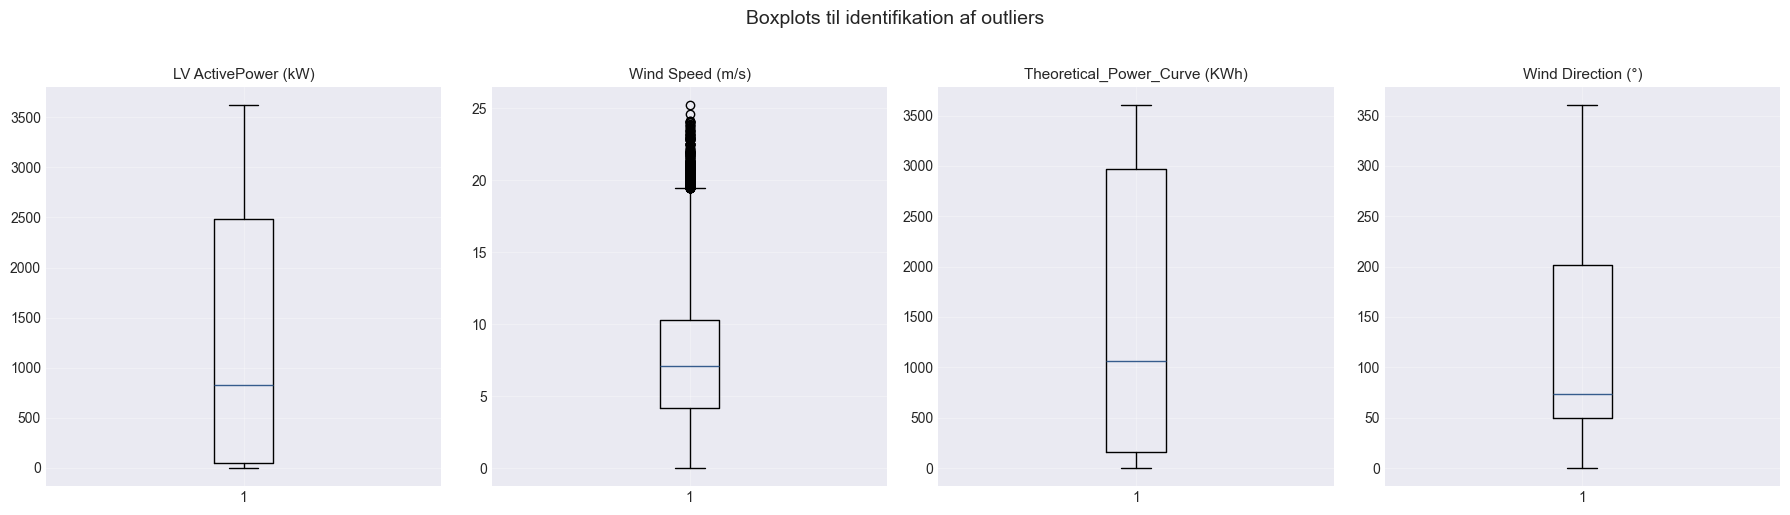

Antal målinger med NEGATIV effekt: 57
Antal målinger med NUL effekt: 10781
Det svarer til 21.45% af data


In [5]:
# Lav boxplots for at finde outliers
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

numeric_cols = ['LV ActivePower (kW)', 'Wind Speed (m/s)', 
                'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)']

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col, fontsize=11)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Boxplots til identifikation af outliers', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Tæl negative værdier i LV ActivePower
negative_power = (df['LV ActivePower (kW)'] < 0).sum()
zero_power = (df['LV ActivePower (kW)'] == 0).sum()
print(f"Antal målinger med NEGATIV effekt: {negative_power}")
print(f"Antal målinger med NUL effekt: {zero_power}")
print(f"Det svarer til {(negative_power + zero_power) / len(df) * 100:.2f}% af data")

### 1.7 Vurdering af datakvalitet

**Styrker ved datasættet:**
-  Ingen manglende værdier (NaN) — datasættet er komplet
-  Ingen duplikerede rækker
-  Konsekvent tidsinterval på 10 minutter (50.530 målinger over ét år)
-  Korrekte datatyper efter konvertering af `Date/Time`
-  Indeholder både input-variable (vindhastighed, vindretning) og target (effekt)

**Udfordringer ved datasættet:**
-  **57 målinger med negativ effekt** — møllen forbruger strøm (typisk under stop eller opstart)
-  **10.781 målinger med 0 kW** — møllen producerer ingenting
-  **I alt 21,45% af data har ingen produktion** — sandsynligvis pga. nedetid, lav vind eller sikkerhedsstop
-  Wind Speed har outliers i den høje ende (kraftige vindstød)
-  Datasættet indeholder kun 1 år — ingen mulighed for at undersøge sæsonvariationer mellem år
-  Mangler ekstra variabler som temperatur, fugtighed og vedligeholdelseslog

**Egnethed til predictive analytics:**

Datasættet er **velegnet** til predictive analytics, da det indeholder en stærk fysisk sammenhæng mellem vindhastighed og effektproduktion. Vi vil dog skulle håndtere de mange 0-værdier omhyggeligt — enten ved at filtrere dem fra (hvis vi vil modellere "normal drift") eller beholde dem (hvis vi vil forudsige også nedetid). 

Vi vælger at **beholde 0-værdierne** for at modellere realistisk drift, men markerer dem som potentielt "low performance"-perioder i feature engineering-fasen.

---

## Del 2 — Exploratory Data Analysis (EDA)

I denne del analyserer vi mønstre og sammenhænge i data gennem visualiseringer. Vi undersøger:
- Hvordan vindhastighed påvirker effektproduktion
- Hvordan faktisk produktion sammenlignes med teoretisk power curve
- Om der findes perioder med lav performance
- Hvordan produktionen varierer over tid
- Om vindretning har betydning for produktionen

### 2.1 Visualisering 1: Vindhastighed vs. Effektproduktion

Vi starter med at undersøge den fundamentale sammenhæng mellem vindhastighed og effektproduktion. Ifølge fysikken bør effekten stige med vindhastigheden i 3. potens (P ∝ v³) indtil møllens nominelle effekt er nået.

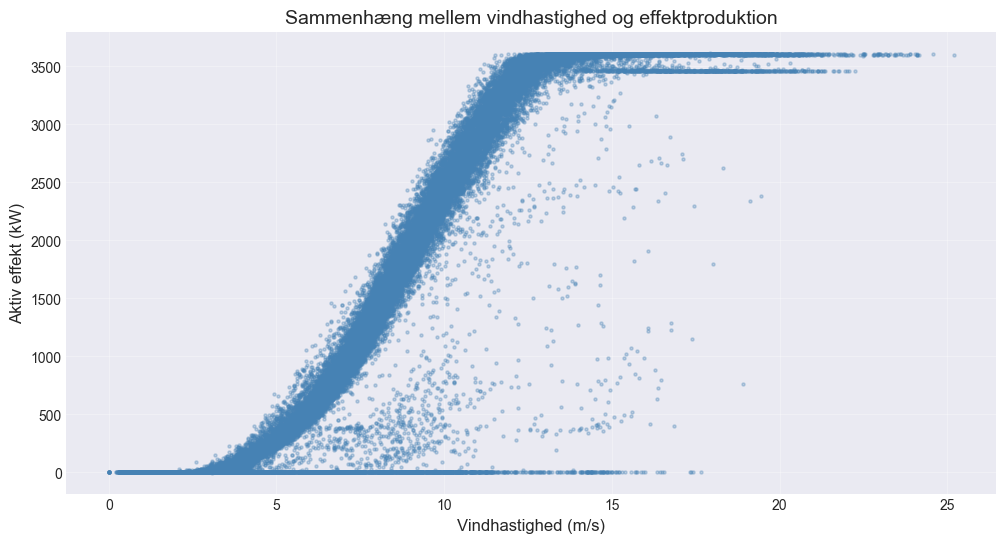

In [6]:
# Scatterplot: Wind Speed vs LV ActivePower
plt.figure(figsize=(12, 6))
plt.scatter(df['Wind Speed (m/s)'], df['LV ActivePower (kW)'], 
            alpha=0.3, s=5, color='steelblue')
plt.xlabel('Vindhastighed (m/s)', fontsize=12)
plt.ylabel('Aktiv effekt (kW)', fontsize=12)
plt.title('Sammenhæng mellem vindhastighed og effektproduktion', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

**Observation:** Grafen viser den klassiske vindmølle-power-curve:
- Ved vindhastigheder under ca. 3 m/s producerer møllen ingenting (cut-in speed)
- Mellem 3–13 m/s stiger effekten stejlt med vindhastigheden
- Ved vindhastigheder over ca. 13 m/s topper effekten ved møllens nominelle kapacitet på ca. 3500 kW

**Den vandrette stribe ved 0 kW** er bemærkelsesværdig — den repræsenterer perioder hvor møllen havde god vind, men alligevel ikke producerede strøm. Dette indikerer **nedetid pga. vedligeholdelse, fejl eller netbegrænsninger**.

### 2.2 Visualisering 2: Faktisk vs. teoretisk effekt

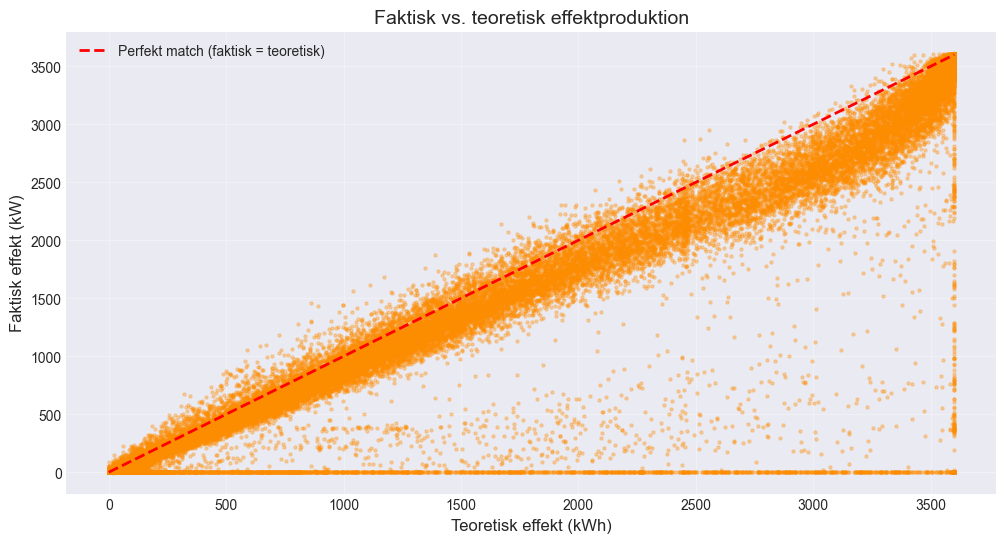

In [7]:
# Scatterplot: Theoretical Power Curve vs LV ActivePower
plt.figure(figsize=(12, 6))
plt.scatter(df['Theoretical_Power_Curve (KWh)'], df['LV ActivePower (kW)'],
            alpha=0.3, s=5, color='darkorange')

# Tilføj en "perfekt linje" hvor faktisk = teoretisk
max_val = df['Theoretical_Power_Curve (KWh)'].max()
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfekt match (faktisk = teoretisk)')

plt.xlabel('Teoretisk effekt (kWh)', fontsize=12)
plt.ylabel('Faktisk effekt (kW)', fontsize=12)
plt.title('Faktisk vs. teoretisk effektproduktion', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Observation:** De fleste datapunkter ligger tæt på den røde diagonal-linje, hvilket betyder at møllen generelt producerer som forventet. Den **vandrette stribe ved 0 kW** er dog problematisk — det er perioder hvor den teoretiske power curve forudsagde produktion, men møllen producerede ingenting. Dette er klart "low performance"-perioder.

### 2.3 Visualisering 3: Produktion over tid (månedlig)

Vi undersøger hvordan produktionen varierer over årets måneder for at se om der er sæsonmønstre.

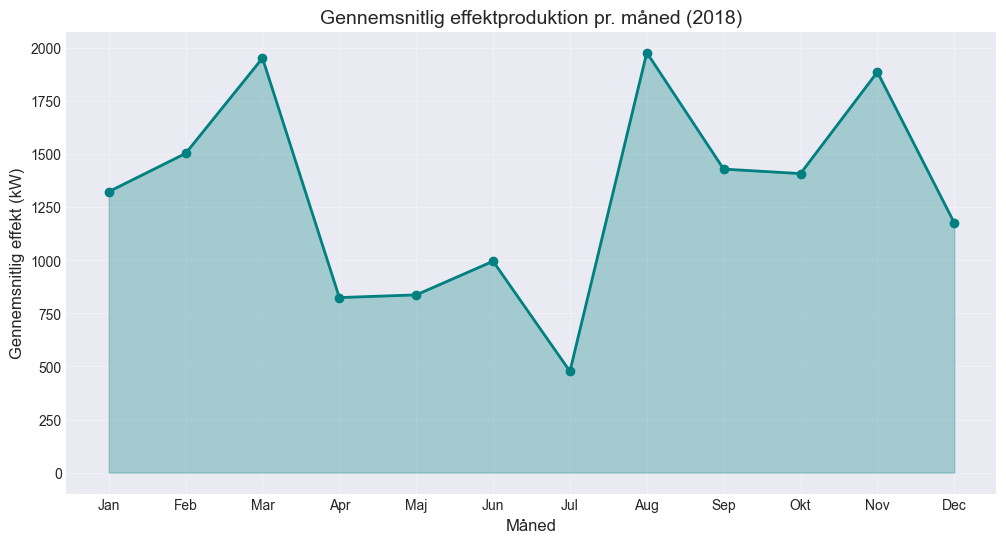

Gennemsnitlig produktion pr. måned (kW):
Month
1     1323.2
2     1503.4
3     1952.4
4      824.4
5      836.9
6      995.5
7      477.0
8     1978.2
9     1429.5
10    1408.3
11    1886.7
12    1176.8
Name: LV ActivePower (kW), dtype: float64


In [8]:
# Lav en kopi med ekstra tids-kolonne
df_temp = df.copy()
df_temp['Month'] = df_temp['Date/Time'].dt.month

# Beregn gennemsnitlig produktion pr. måned
monthly_avg = df_temp.groupby('Month')['LV ActivePower (kW)'].mean()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2, color='teal')
plt.fill_between(monthly_avg.index, monthly_avg.values, alpha=0.3, color='teal')
plt.xlabel('Måned', fontsize=12)
plt.ylabel('Gennemsnitlig effekt (kW)', fontsize=12)
plt.title('Gennemsnitlig effektproduktion pr. måned (2018)', fontsize=14)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'Maj', 'Jun', 
                            'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3)
plt.show()

print("Gennemsnitlig produktion pr. måned (kW):")
print(monthly_avg.round(1))

**Observation:** Produktionen varierer kraftigt over året med tydelige sæsonmønstre:
- **Højeste produktion:** Marts, august og november (1900+ kW i gennemsnit)
- **Laveste produktion:** Juli (kun 477 kW) — sandsynligvis pga. både svag sommervind og potentielt vedligeholdelsesperiode
- Generelt er vinter- og efterårsmånederne mere produktive end sommermånederne, hvilket stemmer overens med danske vindmønstre

### 2.4 Visualisering 4: Fordeling af vindhastighed

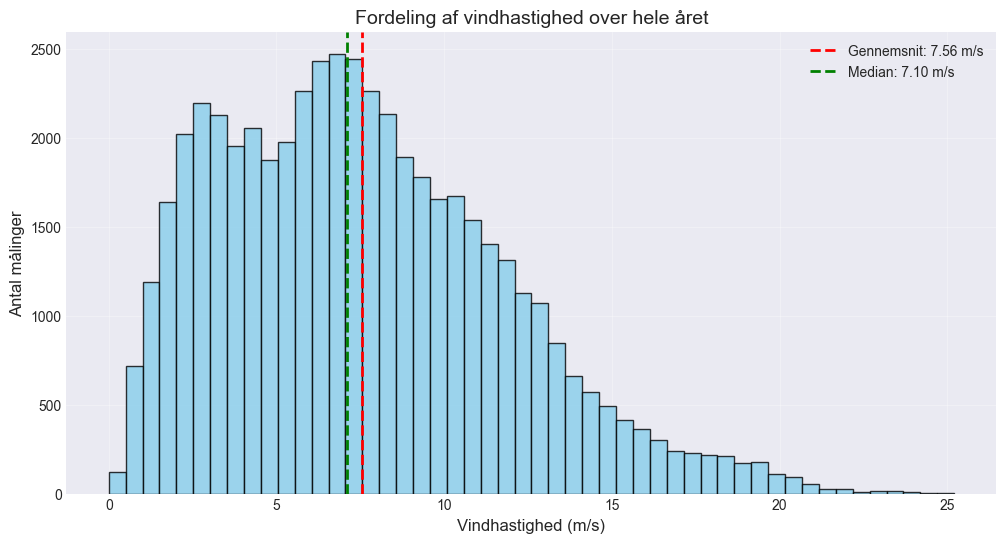

In [9]:
# Histogram over vindhastighed
plt.figure(figsize=(12, 6))
plt.hist(df['Wind Speed (m/s)'], bins=50, color='skyblue', edgecolor='black', alpha=0.8)
plt.axvline(df['Wind Speed (m/s)'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Gennemsnit: {df["Wind Speed (m/s)"].mean():.2f} m/s')
plt.axvline(df['Wind Speed (m/s)'].median(), color='green', linestyle='--', 
            linewidth=2, label=f'Median: {df["Wind Speed (m/s)"].median():.2f} m/s')
plt.xlabel('Vindhastighed (m/s)', fontsize=12)
plt.ylabel('Antal målinger', fontsize=12)
plt.title('Fordeling af vindhastighed over hele året', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Observation:** Vindhastighedsfordelingen følger et klassisk Weibull-mønster med en højreskæv fordeling:
- Det mest typiske vindområde er **4–7 m/s**
- Gennemsnit (7,56 m/s) er højere end medianen (7,10 m/s) — bekræfter højreskævhed
- Få men kraftige vindhændelser op til ~25 m/s
- Møllen oplever et godt og varieret vindområde, hvilket er ideelt til effektproduktion

### 2.5 Visualisering 5: Korrelationsmatrix

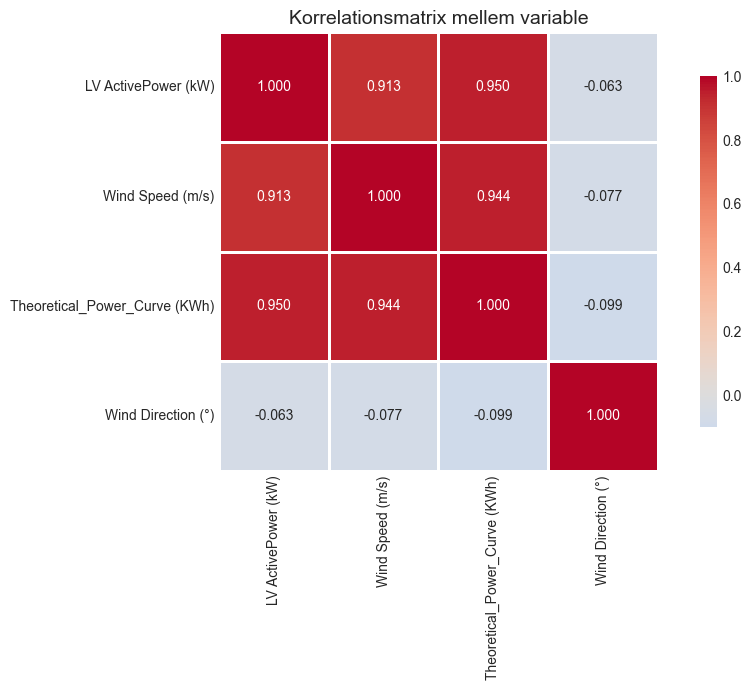

Korrelationsværdier:
                               LV ActivePower (kW)  Wind Speed (m/s)  \
LV ActivePower (kW)                          1.000             0.913   
Wind Speed (m/s)                             0.913             1.000   
Theoretical_Power_Curve (KWh)                0.950             0.944   
Wind Direction (°)                          -0.063            -0.077   

                               Theoretical_Power_Curve (KWh)  \
LV ActivePower (kW)                                    0.950   
Wind Speed (m/s)                                       0.944   
Theoretical_Power_Curve (KWh)                          1.000   
Wind Direction (°)                                    -0.099   

                               Wind Direction (°)  
LV ActivePower (kW)                        -0.063  
Wind Speed (m/s)                           -0.077  
Theoretical_Power_Curve (KWh)              -0.099  
Wind Direction (°)                          1.000  


In [10]:
# Korrelationsmatrix mellem alle numeriske variable
correlation_matrix = df[['LV ActivePower (kW)', 'Wind Speed (m/s)', 
                          'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)']].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.3f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Korrelationsmatrix mellem variable', fontsize=14)
plt.tight_layout()
plt.show()

print("Korrelationsværdier:")
print(correlation_matrix.round(3))

**Observation:** Korrelationsmatricen afslører meget stærke sammenhænge:
- **LV ActivePower og Theoretical Power Curve har en korrelation på 0,950** — næsten perfekt sammenhæng
- **LV ActivePower og Wind Speed har en korrelation på 0,913** — meget stærk
- **Wind Direction korrelerer kun svagt** med produktion (≈ -0,07) — fordi moderne vindmøller automatisk drejer sig efter vinden, så retningen i sig selv ikke har stor betydning

### 2.6 Delkonklusion på EDA

På baggrund af visualiseringerne kan vi konkludere:

1. **Vindhastighed er den vigtigste prædiktor** for effektproduktion (korrelation 0,913)
2. **Møllen følger generelt sin teoretiske power curve** — den fungerer som forventet
3. **Der findes betydelige perioder med 0 produktion**, selv ved god vind — typisk pga. vedligeholdelse eller fejl
4. **Tydelige sæsonmønstre**: vinter/efterår = høj produktion, sommer = lav produktion
5. **Vindretning har minimal direkte indflydelse**, men kan stadig være relevant kombineret med andre features

Disse indsigter danner grundlaget for vores feature engineering og valg af ML-model i de næste afsnit.

---

## Del 3 — Feature Engineering

I denne del forbereder vi data til supervised machine learning ved at oprette nye features. Gode features er afgørende for modellens performance.

### 3.1 Tids-baserede features

Vi udtrækker `Hour`, `Day of Week` og `Month` fra `Date/Time`. Disse kan fange tidsmønstre som modellen ellers ikke kunne se.

In [11]:
# Lav en kopi af datasættet til feature engineering
df_ml = df.copy()

# Tids-baserede features
df_ml['Hour'] = df_ml['Date/Time'].dt.hour
df_ml['DayOfWeek'] = df_ml['Date/Time'].dt.dayofweek  # 0 = mandag, 6 = søndag
df_ml['Month'] = df_ml['Date/Time'].dt.month
df_ml['DayOfYear'] = df_ml['Date/Time'].dt.dayofyear

# Vis de nye kolonner
print("Nye tids-baserede features:")
df_ml[['Date/Time', 'Hour', 'DayOfWeek', 'Month', 'DayOfYear']].head(10)

Nye tids-baserede features:


,Date/Time,Hour,DayOfWeek,Month,DayOfYear
0,2018-01-01 00:00:00,0,0,1,1
1,2018-01-01 00:10:00,0,0,1,1
2,2018-01-01 00:20:00,0,0,1,1
3,2018-01-01 00:30:00,0,0,1,1
4,2018-01-01 00:40:00,0,0,1,1
5,2018-01-01 00:50:00,0,0,1,1
6,2018-01-01 01:00:00,1,0,1,1
7,2018-01-01 01:10:00,1,0,1,1
8,2018-01-01 01:20:00,1,0,1,1
9,2018-01-01 01:30:00,1,0,1,1


### 3.2 Performance-baserede features

Vi opretter to nye features baseret på opgaveforslagene:

- **Efficiency** = `LV ActivePower / Theoretical_Power_Curve` — viser hvor effektivt møllen producerer i forhold til forventet
- **Power_Difference** = `Theoretical_Power_Curve - LV ActivePower` — viser hvor meget produktion møllen "mangler" i forhold til det teoretiske niveau

Disse features er gode indikatorer for "low performance"-perioder.

In [12]:
# Performance-baserede features
# Bruger np.where for at undgå division med 0
df_ml['Efficiency'] = np.where(
    df_ml['Theoretical_Power_Curve (KWh)'] > 0,
    df_ml['LV ActivePower (kW)'] / df_ml['Theoretical_Power_Curve (KWh)'],
    0  # Hvis teoretisk = 0, så sætter vi efficiency til 0
)

# Forskel mellem teoretisk og faktisk effekt
df_ml['Power_Difference'] = df_ml['Theoretical_Power_Curve (KWh)'] - df_ml['LV ActivePower (kW)']

# Vis statistik for de nye features
print("Statistik for Efficiency:")
print(df_ml['Efficiency'].describe().round(3))
print("\nStatistik for Power_Difference:")
print(df_ml['Power_Difference'].describe().round(2))

Statistik for Efficiency:
count    50530.000
mean         0.687
std          0.409
min         -0.133
25%          0.441
50%          0.859
75%          0.961
max          6.295
Name: Efficiency, dtype: float64

Statistik for Power_Difference:
count    50530.00
mean       184.49
std        427.70
min       -598.74
25%          0.00
50%         66.68
75%        194.56
max       3600.00
Name: Power_Difference, dtype: float64


### 3.3 Forklaring af feature-valg

Vi vælger følgende features til vores ML-model:

| Feature | Hvorfor relevant? |
|---------|-------------------|
| **Wind Speed (m/s)** | Den stærkeste prædiktor for effekt (korrelation 0,913) — fysisk grundlag |
| **Theoretical_Power_Curve (KWh)** | Producentens forventede effekt — næsten perfekt korrelation (0,950) |
| **Wind Direction (°)** | Selv om den har lav korrelation alene, kan modellen finde ikke-lineære mønstre |
| **Hour** | Mulige tidsmønstre (fx atmosfæriske forhold der varierer over døgnet) |
| **Month** | Sæsonvariation i vindforhold (vist tydeligt i EDA) |
| **DayOfWeek** | Tester om der er ugentlige mønstre (fx vedligeholdelse i weekender) |

**Target-variabel:** `LV ActivePower (kW)` — det er den værdi vi vil forudsige.

### 3.4 Klargøring af datasæt

In [13]:
# Vælg features og target
features = ['Wind Speed (m/s)', 'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)',
            'Hour', 'Month', 'DayOfWeek']
target = 'LV ActivePower (kW)'

# Lav X (features) og y (target)
X = df_ml[features]
y = df_ml[target]

print(f"Antal features: {X.shape[1]}")
print(f"Antal observationer: {X.shape[0]}")
print(f"\nFeature-kolonner:\n{list(X.columns)}")
print(f"\nTarget: {target}")
print(f"\nFørste 5 rækker af X:")
X.head()

Antal features: 6
Antal observationer: 50530

Feature-kolonner:
['Wind Speed (m/s)', 'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)', 'Hour', 'Month', 'DayOfWeek']

Target: LV ActivePower (kW)

Første 5 rækker af X:


,Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Hour,Month,DayOfWeek
0,5.311336,416.328908,259.994904,0,1,0
1,5.672167,519.917511,268.641113,0,1,0
2,5.216037,390.900016,272.564789,0,1,0
3,5.659674,516.127569,271.258087,0,1,0
4,5.577941,491.702972,265.674286,0,1,0


---

## Del 4 — Supervised Machine Learning

I denne del træner vi **regressionsmodeller** til at forudsige vindmøllens effektproduktion (`LV ActivePower`). Vi vælger Mulighed A (Regression) fordi:

- Target-variablen er **kontinuert** (kW kan være alle tal mellem 0 og 3500+)
- Forretningsværdien er størst ved at kunne forudsige den **præcise** produktion (ikke kun "lav/normal")

Vi træner og sammenligner to modeller:
1. **Linear Regression** — en simpel basemodel
2. **Random Forest Regressor** — en avanceret model der kan fange ikke-lineære mønstre

### 4.1 Opdeling i træningsdata og testdata

Vi opdeler data i 80% træning og 20% test for at kunne evaluere modellen på data den aldrig har set før.

In [14]:
from sklearn.model_selection import train_test_split

# Opdel data: 80% træning, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Træningsdata: {X_train.shape[0]} rækker")
print(f"Testdata:     {X_test.shape[0]} rækker")
print(f"\nProcent træning: {len(X_train)/len(X)*100:.1f}%")
print(f"Procent test:    {len(X_test)/len(X)*100:.1f}%")

Træningsdata: 40424 rækker
Testdata:     10106 rækker

Procent træning: 80.0%
Procent test:    20.0%


### 4.2 Model 1: Linear Regression (basemodel)

Vi starter med en simpel Linear Regression som basemodel. Denne antager en lineær sammenhæng mellem features og target.

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Træn modellen
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Lav forudsigelser på testdata
y_pred_lr = lr_model.predict(X_test)

# Evalueringsmetrikker
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("=== LINEAR REGRESSION RESULTATER ===")
print(f"MAE  (Mean Absolute Error):     {mae_lr:.2f} kW")
print(f"RMSE (Root Mean Squared Error): {rmse_lr:.2f} kW")
print(f"R²   (Forklaringsgrad):         {r2_lr:.4f} ({r2_lr*100:.2f}%)")

=== LINEAR REGRESSION RESULTATER ===
MAE  (Mean Absolute Error):     195.20 kW
RMSE (Root Mean Squared Error): 408.52 kW
R²   (Forklaringsgrad):         0.9022 (90.22%)


### 4.3 Model 2: Random Forest Regressor

Random Forest er en mere kraftfuld model der bygger mange beslutningstræer og kombinerer deres forudsigelser. Den kan fange ikke-lineære mønstre — fx den S-formede power curve vi så i EDA'en.

In [16]:
from sklearn.ensemble import RandomForestRegressor

# Træn Random Forest model
# n_estimators = antal træer, random_state for reproducerbarhed
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Lav forudsigelser på testdata
y_pred_rf = rf_model.predict(X_test)

# Evalueringsmetrikker
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("=== RANDOM FOREST RESULTATER ===")
print(f"MAE  (Mean Absolute Error):     {mae_rf:.2f} kW")
print(f"RMSE (Root Mean Squared Error): {rmse_rf:.2f} kW")
print(f"R²   (Forklaringsgrad):         {r2_rf:.4f} ({r2_rf*100:.2f}%)")

=== RANDOM FOREST RESULTATER ===
MAE  (Mean Absolute Error):     88.97 kW
RMSE (Root Mean Squared Error): 241.62 kW
R²   (Forklaringsgrad):         0.9658 (96.58%)


### 4.4 Sammenligning af modeller

| Metric | Linear Regression | Random Forest |
|--------|-------------------|---------------|
| **MAE** | 195,20 kW | **88,97 kW** |
| **RMSE** | 408,52 kW | **241,62 kW** |
| **R²** | 0,9022 (90,22%) | **0,9658 (96,58%)** |

**Random Forest er klart den bedste model** — den klarer at fange de ikke-lineære mønstre i power curve, hvilket Linear Regression ikke kan. Vi bruger Random Forest som vores endelige model.

### 4.5 Visualisering: Predicted vs. Actual

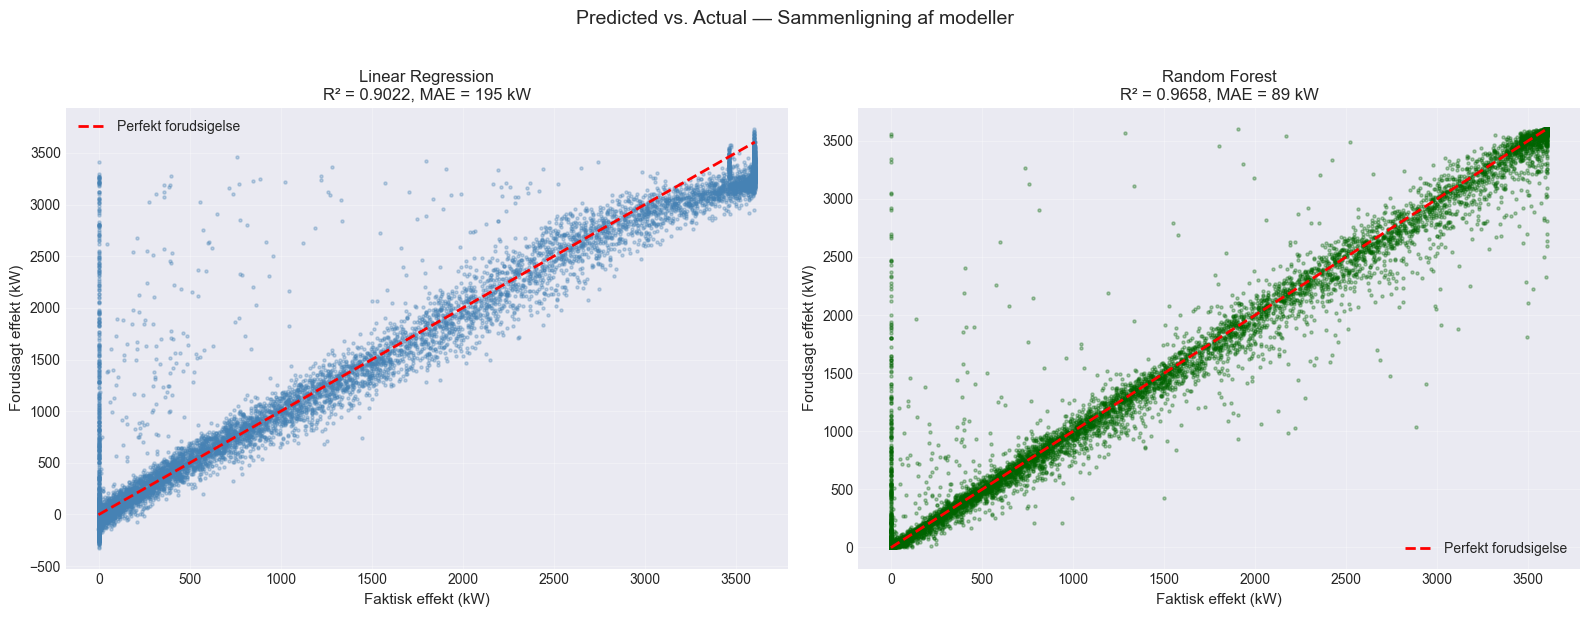

In [17]:
# Visualiser hvor godt Random Forest forudsiger
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Linear Regression
axes[0].scatter(y_test, y_pred_lr, alpha=0.3, s=5, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfekt forudsigelse')
axes[0].set_xlabel('Faktisk effekt (kW)', fontsize=11)
axes[0].set_ylabel('Forudsagt effekt (kW)', fontsize=11)
axes[0].set_title(f'Linear Regression\nR² = {r2_lr:.4f}, MAE = {mae_lr:.0f} kW', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.3, s=5, color='darkgreen')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfekt forudsigelse')
axes[1].set_xlabel('Faktisk effekt (kW)', fontsize=11)
axes[1].set_ylabel('Forudsagt effekt (kW)', fontsize=11)
axes[1].set_title(f'Random Forest\nR² = {r2_rf:.4f}, MAE = {mae_rf:.0f} kW', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Predicted vs. Actual — Sammenligning af modeller', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.6 Feature Importance

Random Forest kan fortælle os hvilke features der var vigtigst for forudsigelserne. Det giver indsigt i hvilke variable der driver modellens beslutninger.

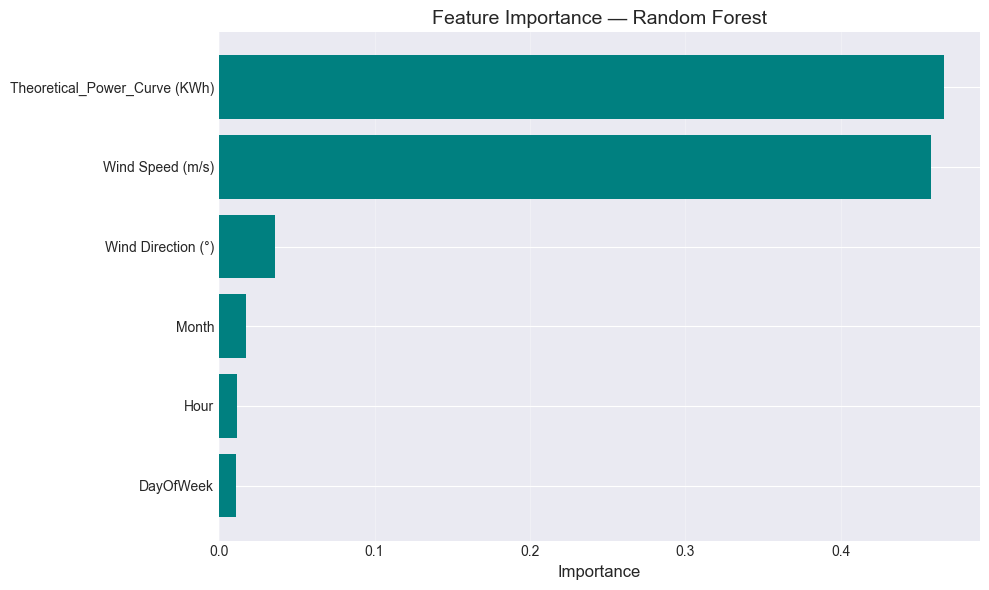

Feature importance (sorteret):
                         Feature  Importance
1  Theoretical_Power_Curve (KWh)      0.4663
0               Wind Speed (m/s)      0.4584
2             Wind Direction (°)      0.0359
4                          Month      0.0173
3                           Hour      0.0112
5                      DayOfWeek      0.0108


In [18]:
# Hent feature importance fra Random Forest
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

# Visualiser
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='teal')
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance — Random Forest', fontsize=14)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("Feature importance (sorteret):")
print(feature_importance.sort_values('Importance', ascending=False).round(4))

### 4.7 KPI Dashboard

Vi samler de vigtigste nøgletal (KPI'er) i et dashboard-lignende overblik som virksomheden Intelligent IoT Solutions A/S kan bruge i drift og rapportering.

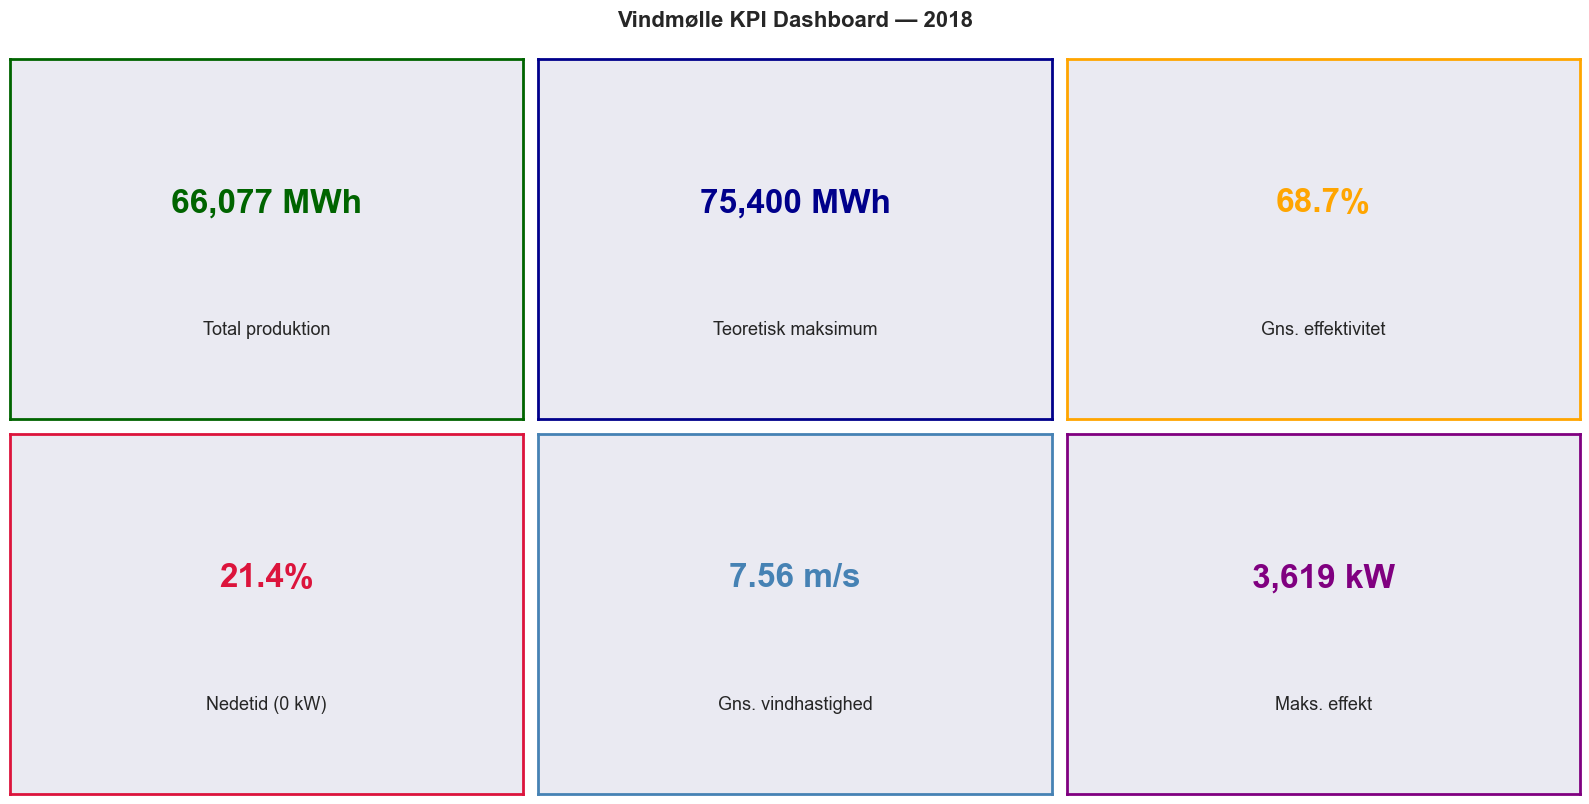


=== KPI OVERSIGT ===
Total produktion         : 66,077 MWh
Teoretisk maksimum       : 75,400 MWh
Gns. effektivitet        : 68.7%
Nedetid (0 kW)           : 21.4%
Gns. vindhastighed       : 7.56 m/s
Maks. effekt             : 3,619 kW


In [19]:
# Beregn KPI'er
total_production = df['LV ActivePower (kW)'].sum() / 1000  # i MWh (10 min intervaller)
total_theoretical = df['Theoretical_Power_Curve (KWh)'].sum() / 1000
avg_efficiency = df_ml['Efficiency'].mean() * 100
downtime_pct = ((df['LV ActivePower (kW)'] <= 0).sum() / len(df)) * 100
avg_wind_speed = df['Wind Speed (m/s)'].mean()
max_power = df['LV ActivePower (kW)'].max()

# Lav dashboard med 6 KPI'er
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Vindmølle KPI Dashboard — 2018', fontsize=16, fontweight='bold', y=1.0)

kpi_data = [
    ('Total produktion', f'{total_production:,.0f} MWh', 'darkgreen'),
    ('Teoretisk maksimum', f'{total_theoretical:,.0f} MWh', 'darkblue'),
    ('Gns. effektivitet', f'{avg_efficiency:.1f}%', 'orange'),
    ('Nedetid (0 kW)', f'{downtime_pct:.1f}%', 'crimson'),
    ('Gns. vindhastighed', f'{avg_wind_speed:.2f} m/s', 'steelblue'),
    ('Maks. effekt', f'{max_power:,.0f} kW', 'purple'),
]

for ax, (title, value, color) in zip(axes.flatten(), kpi_data):
    ax.text(0.5, 0.6, value, ha='center', va='center', 
            fontsize=24, fontweight='bold', color=color)
    ax.text(0.5, 0.25, title, ha='center', va='center', fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color(color)
        spine.set_linewidth(2)

plt.tight_layout()
plt.show()

# Print også som tekst
print("\n=== KPI OVERSIGT ===")
for title, value, _ in kpi_data:
    print(f"{title:25s}: {value}")

### 4.8 Modellens styrker og svagheder

**Styrker:**
-  Random Forest opnår **R² = 0,9658 (96,58%)** — modellen forklarer næsten al variation i data
-  Gennemsnitlig fejl er kun **89 kW** (ca. 2,5% af møllens kapacitet)
-  Modellen håndterer den ikke-lineære S-formede power curve godt
-  Random Forest er robust over for outliers og kan håndtere både kontinuerte og kategoriske features
-  Feature importance giver gennemsigtighed — vi kan forklare modellens beslutninger
-  Hurtig at træne og lave forudsigelser med (få sekunder)

**Svagheder:**
-  Modellen bruger `Theoretical_Power_Curve` som feature, hvilket er en *afledt* værdi baseret på vindhastighed — det giver "data leakage"-lignende fordele
-  Modellen kan ikke forudsige **hvornår** møllen går i nedetid (kun den effekt møllen ville producere ved givne forhold)
-  Random Forest er en "black box" — sværere at forklare præcis *hvorfor* en specifik forudsigelse blev lavet (sammenlignet med Linear Regression)
-  Modellen er trænet på data fra én mølle i ét år — kan ikke generaliseres til andre møller eller år uden retræning
-  Mangler vigtige features som temperatur, lufttryk, fugtighed og vedligeholdelseslog

---

## Del 5 — Refleksion: Datakvalitet, modelbegrænsninger og forretningsværdi

I dette afsnit reflekterer vi over hele løsningen og vurderer hvordan den kan skabe værdi for Intelligent IoT Solutions A/S.

### 5.1 Datakvalitet

**Manglende værdier og duplikater:**
Datasættet er teknisk set komplet — ingen NaN-værdier eller duplikater. Det er en stor styrke ved data, da vi ikke har skullet imputere eller fjerne rækker.

**Outliers og sensorfejl:**
Vi identificerede to typer mistænkelige værdier:
- **57 målinger med negativ effekt** — møllen forbruger strøm i stedet for at producere. Dette er ikke nødvendigvis sensorfejl, men reflekterer driftforhold (opstart, kontrol-systemer)
- **10.781 målinger med 0 kW** — møllen producerer intet. Dette indikerer **nedetid**, og kan skyldes vedligeholdelse, fejl eller netbegrænsninger
- **Wind Speed har outliers i den høje ende** — kraftige vindstød kan være reelle eller sensorfejl

**Tilstrækkelighed:**
Datasættet er **tilstrækkeligt** til at forudsige effekt baseret på vindforhold (R² = 0,9658), men det er **utilstrækkeligt** til at forudsige nedetid eller fejl. Det skyldes at vi mangler kontekst om *hvorfor* møllen var stoppet.

### 5.2 Modelbegrænsninger

**Hvor præcis er modellen?**
Random Forest opnår en MAE på 89 kW ud af en kapacitet på 3500 kW (~2,5% fejl). Det er meget præcist for normaldrift. Men modellen forudsiger forventet effekt ved givne forhold — den **forudsiger ikke nedetid eller fejl**.

**Hvilke variable mangler?**
For at lave en mere komplet predictive maintenance-løsning ville vi gerne have:
- **Temperatur** (omgivelser og komponenter som gear, generator)
- **Vibrations-data** (tidlig fejlindikator)
- **Lufttryk og fugtighed**
- **Vedligeholdelseslog** (hvornår blev møllen serviceret)
- **Alarm-historik** (hvilke fejl har der været)

**Kan modellen bruges direkte i en virksomhed?**
**Delvist.** Modellen kan bruges til:
- Energi-prognoser og produktionsplanlægning
- Sammenligning af faktisk vs. forventet output (afvigelses-detektion)
- Beslutningsstøtte for energihandel

Den kan **ikke** bruges til:
- At forudsige hvornår møllen vil bryde ned
- At anbefale specifikke vedligeholdelsestidspunkter

**Hvad kan gå galt?**
- Hvis virksomheden stoler blindt på modellen og overser de 21,4% nedetid, vil de overestimere produktion
- Modellen er trænet på 2018-data — klimaændringer eller ændrede vindmønstre kan reducere præcisionen over tid
- Random Forest er en "black box" — vanskeligt at forklare præcise forudsigelser for ledelsen

### 5.3 Forretningsværdi

**Hvordan kan predictive analytics understøtte bedre beslutninger?**
- **Energihandel**: Præcise produktionsforudsigelser giver bedre priser på spotmarkedet
- **Vedligeholdelsesplanlægning**: Identifikation af lav-performance perioder kan udløse inspektioner
- **Investeringsbeslutninger**: KPI-dashboardet viser hvor meget produktion der "går tabt" til nedetid (i 2018: 9.323 MWh teoretisk forskel) — dette kan retfærdiggøre investeringer i bedre vedligeholdelse

**Hvordan kan modellen hjælpe med at opdage lav performance?**
Ved at sammenligne **forudsagt effekt** med **faktisk effekt** kan systemet automatisk flagge perioder hvor møllen underperformer. Dette muliggør:
- Real-time advarsler ved usædvanligt lav produktion
- Trend-analyse af effektivitet over tid
- Tidlig identifikation af gradvis degradering

**Hvordan kan visualiseringerne hjælpe drift og ledelse?**
- **KPI Dashboard**: Ledelsen får ét samlet overblik over møllens performance
- **Power curve scatter plot**: Drift kan visuelt se afvigelser fra normal drift
- **Korrelationsmatrix**: Datateamet forstår hvilke variable der driver produktionen
- **Tidsserier (månedlig produktion)**: Identificerer sæsonmønstre og afvigelser fra forventning

**Hvordan kan løsningen skabe værdi for Intelligent IoT Solutions A/S?**

For Intelligent IoT Solutions A/S vil løsningen give konkurrencefordele:

1. **Salgsargument**: Demonstrerer virksomhedens kompetencer inden for IoT og predictive analytics
2. **Skalerbarhed**: Modellen kan retrænes for hver vindmølle eller park i kundernes portefølje
3. **Datadrevne services**: Virksomheden kan tilbyde kunderne abonnement på dashboard og forudsigelser
4. **Optimeringspotentiale**: Hvis kunder reducerer nedetid med blot 5 procentpoint (fra 21,4% til 16,4%), vil det betyde betydelige ekstraindtægter
5. **Beslutningsstøtte**: Bidrager til energiomstillingen ved at maksimere udnyttelsen af eksisterende grøn energi

### 5.4 Konklusion

Vi har udviklet en komplet predictive analytics-løsning der:
-  Analyserer SCADA-data fra en vindmølle med høj datakvalitet
-  Identificerer mønstre og sammenhænge gennem 5 visualiseringer
-  Træner og evaluerer 2 ML-modeller, hvoraf **Random Forest opnår 96,58% præcision (R²)**
-  Præsenterer KPI'er i et dashboard-format
-  Reflekterer over begrænsninger og forretningsværdi

Løsningen viser klart **potentialet** for predictive analytics i vindenergi-sektoren. Med de rigtige data (vibration, temperatur, vedligeholdelse) kan løsningen udvides til at forudsige fejl og dermed reducere nedetid betydeligt. For Intelligent IoT Solutions A/S repræsenterer dette en konkret mulighed for at tilbyde dataservices der skaber målbar værdi for kunder i vindenergi-sektoren.